
 ### 학습 데이터 정보 ### 

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
데이터 세트 Null 값 개수  0
 Sex 값 분포 :
 Sex
male      577
female    314
Name: count, dtype: int64

 Cabin 값 분포 :
 Cabin
N              687
G6               4
C23 C25 C27      4
B96 B98          4
F33              3
              ... 
E17  

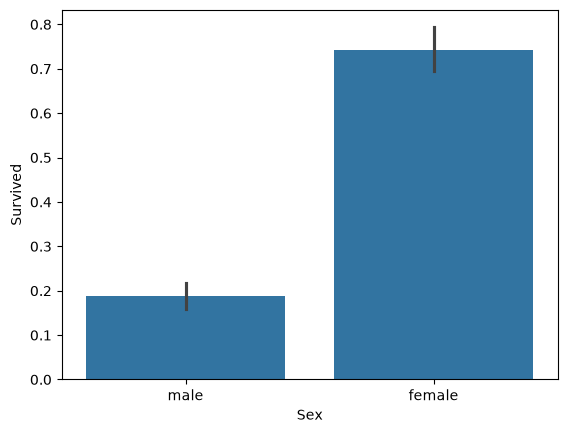

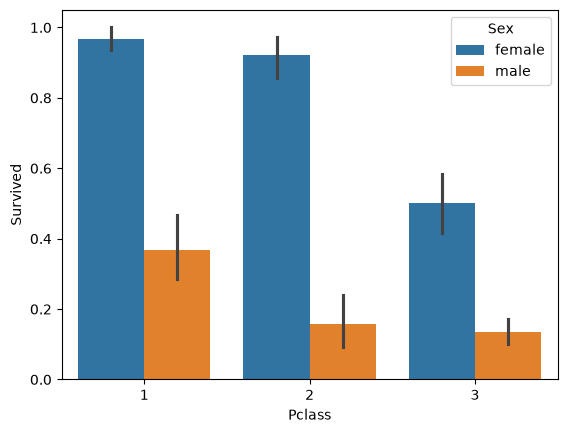

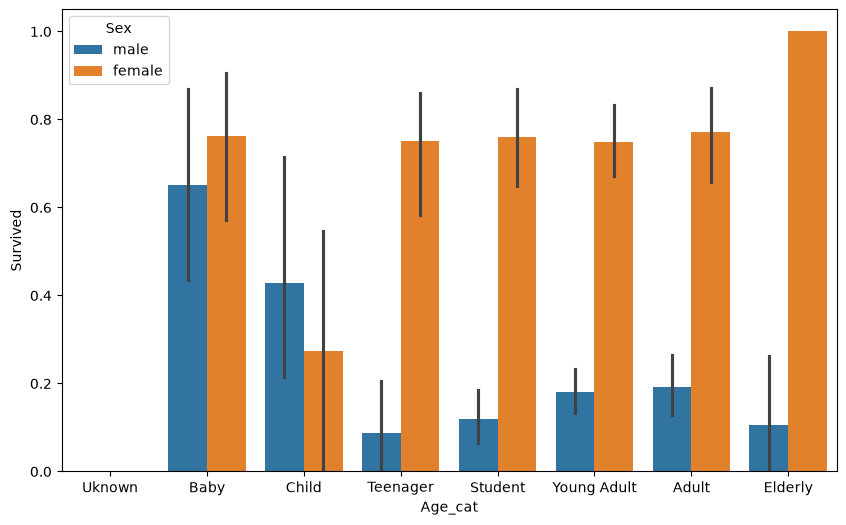

In [19]:
# 타이타닉 생존자 예측
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
titanic_df = pd.read_csv('./data/titanic.csv')
titanic_df.head(3)

print('\n ### 학습 데이터 정보 ### \n')
# RangleIndex: DataFrame 인덱스의 범위를 나타냄 - 전체 raw 수를 알 수 있음
print(titanic_df.info())

# 사이킷런 머신러닝 알고리즘은 Null 값을 허용하지 않음

# DataFrame의 fillna() 함수를 이용해 Null 값을 평균 또는 고정 값으로 변경(아래 주석은 pandas 버전 이슈로 사용X)
# titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)
# titanic_df['Cabin'].fillna('N', inplace=True)
# titanic_df['Embarked'].fillna('N', inplace=True)

titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('N')
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('N')
print('데이터 세트 Null 값 개수 ', titanic_df.isnull().sum().sum())

print(' Sex 값 분포 :\n', titanic_df['Sex'].value_counts())
print('\n Cabin 값 분포 :\n', titanic_df['Cabin'].value_counts())
print('\n Embarked 값 분포 :\n', titanic_df['Embarked'].value_counts())

# 삼등석 보다는 일등석에 투숙한 사람들의 생존할 확률이 더 높음
# Cabin에서 선실 등급을 나타내는 첫 번째 알파벳 추출
print('\n')
titanic_df['Cabin'] = titanic_df['Cabin'].str[:1]
print(titanic_df['Cabin'].head(3))

# 우선 구조 대상: 여성과 아이, 노약자
# 성별에 따른 생존자
print('\n')
titanic_df.groupby(['Sex', 'Survived'])['Survived'].count()
# seaborn으로 시각화
sns.barplot(x='Sex', y='Survived', data=titanic_df)
plt.show()

# 객실 등급별 성별에 따른 생존 확률
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)
plt.show()

# 입력 age에 따라 구분 값을 반환하는 함수 설정. DataFrame의 apply lambda 식에 사용
def get_category(age):
    cat = ''
    if age <= -1: cat = 'Unknown'
    elif age <= 5: cat = 'Baby'
    elif age <= 12: cat = 'Child'
    elif age <= 18: cat = 'Teenager'
    elif age <= 25: cat = 'Student'
    elif age <= 35: cat = 'Young Adult'
    elif age <= 60: cat = 'Adult'
    else: cat = 'Elderly'

    return cat

# 막대그래프의 크기 figure를 더 크게 설정
plt.figure(figsize=(10, 6))

# X축의 값을 순차적으로 표시하기 위한 설정
group_names = ['Uknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']

# lambda 식에 위에서 생성한 get_category() 함수를 반환값으로 지정
# get_category(X)는 입력값으로 'Age' 칼럼 값을 받아서 해당하는 cat 반환
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x: get_category(x))
sns.barplot(x='Age_cat', y='Survived', hue='Sex', data=titanic_df, order=group_names)
titanic_df.drop('Age_cat', axis=1, inplace=True)

In [23]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

def encode_features(dataDF):
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(dataDF[feature])
        dataDF[feature] = le.transform(dataDF[feature])

    return dataDF

titanic_df = encode_features(titanic_df)
titanic_df.head()

# Null 처리 함수
def fillna(df):
    titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())
    titanic_df['Cabin'] = titanic_df['Cabin'].fillna('N')
    titanic_df['Embarked'] = titanic_df['Embarked'].fillna('N')
    titanic_df['Fare'] = titanic_df['Fare'].fillna(0)
    return df

# 머신러닝 알고리즘에 불필요한 피처 제거
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 레이블 인코딩 수행
def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

# 원본 데이터를 재로딩하고, 피처 데이터 세트와 레이블 데이터 세트 추출
titanic_df = pd.read_csv('./data/titanic.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)

X_titanic_df = transform_features(X_titanic_df)

X_train, X_test, y_train, y_test=train_test_split(X_titanic_df, y_titanic_df, test_size=0.2, ran